# Unsupervised Methods: Topic Modeling and Clustering<div class='tocSkip'/>

## Setup<div class='tocSkip'/>

Set directory locations. If working on Google Colab: copy files and install required libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# suppress warnings
import warnings;
warnings.filterwarnings('ignore');

# common imports
import pandas as pd
import numpy as np
import math
import re
import glob
import os
import sys
import json
import random
import pprint as pp
import textwrap
import sqlite3
import logging

import spacy
import nltk

from tqdm.auto import tqdm
# register `pandas.progress_apply` and `pandas.Series.map_apply` with `tqdm`
tqdm.pandas()

# pandas display options
# https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html#available-options
pd.options.display.max_columns = 30 # default 20
pd.options.display.max_rows = 60 # default 60
pd.options.display.float_format = '{:.2f}'.format
# pd.options.display.precision = 2
pd.options.display.max_colwidth = 200 # default 50; -1 = all
# otherwise text between $ signs will be interpreted as formula and printed in italic
pd.set_option('display.html.use_mathjax', False)

# np.set_printoptions(edgeitems=3) # default 3

import matplotlib
from matplotlib import pyplot as plt

plot_params = {'figure.figsize': (8, 4),
               'axes.labelsize': 'large',
               'axes.titlesize': 'large',
               'xtick.labelsize': 'large',
               'ytick.labelsize':'large',
               'figure.dpi': 100}
# adjust matplotlib defaults
matplotlib.rcParams.update(plot_params)

import seaborn as sns
sns.set_style("darkgrid")

import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
BASE_DIR = '/content/drive/MyDrive/ESCP/NLP/04_topic_modeling'
os.chdir(BASE_DIR)

# Load data

In [ ]:
import pandas as pd
DEBATES_FILE = './data/un-general-debates-blueprint.csv.gz'
df = pd.read_csv(DEBATES_FILE)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7507 entries, 0 to 7506
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   session       7507 non-null   int64 
 1   year          7507 non-null   int64 
 2   country       7507 non-null   object
 3   country_name  7507 non-null   object
 4   speaker       7480 non-null   object
 5   position      4502 non-null   object
 6   text          7507 non-null   object
dtypes: int64(2), object(5)
memory usage: 410.7+ KB


In [ ]:
print(repr(df.iloc[0]["text"][0:200]))
print(repr(df.iloc[-1]["text"][0:200]))

'33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly?\n34.\tIn taking up the work '
'Allow me at the outset to extend to Mr. Mogens Lykketoft my warm congratulations on his election to the high office of President of the General Assembly at its seventieth session. He assumes this offi'


In [ ]:
df.loc[0,"text"]

"33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly?\n34.\tIn taking up the work on the agenda of the twenty- fifth session of the General Assembly, which is being held on the eve of the twenty-fifth anniversary of the coming into force of the Charter of the United Nations, the peace-loving Member States would have wished to be in a position to present on this occasion some picture of positive and satisfactory activity on the part of the United Nations. The Albanian delegation, for its part, would have taken great pleasure in drawing up such a balance sheet of activities covering a quarter of a century, which is certainly no short period in the life of an international organization. Unfortunately, this is not the situation. Created on the day after victory had been achieved over the Powers of the Rome BerlinTokyo Axis and conceived in the spirit of the principles wh

In [ ]:
df.loc[7506,"text"]

'Allow me at the outset to extend to Mr. Mogens Lykketoft my warm congratulations on his election to the high office of President of the General Assembly at its seventieth session. He assumes this office at an historic moment when the United Nations has just adopted an ambitious agenda for the future of humankind. The task ahead needs all hands on deck and he can count on our cooperation and support during his presidency.\nI wish to commend Mr. Sam Kutesa, a distinguished son of Africa, for the dynamism with which he steered this body over the past year. We particularly appreciated his leadership in promoting inclusive dialogue and seeking consensus on the many sensitive issues that he presided over during his tenure of office.\nThe theme of this session — “The United Nations at 70: the road ahead for peace, security and human rights” — aptly complements the deliberations of the Summit meeting on the post-2015 development agenda. It is our expectation that the United Nations will draw 

# Split and analyze

In [ ]:
import re
df["paragraphs"] = df["text"].map(lambda text: re.split('[.?!]\s*\n', text))

In [ ]:
df.head(2)

,session,year,country,country_name,speaker,position,text,paragraphs
0,25,1970,ALB,Albania,Mr. NAS,NaN,33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly?\n34.\tIn taking up the...,"[33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly, 34.\tIn taking up the..."
1,25,1970,ARG,Argentina,Mr. DE PABLO PARDO,NaN,"177.\t : It is a fortunate coincidence that precisely at a time when the United Nations is celebrating its first twenty-five years of existence, an eminent jurist so closely linked to our Organiza...","[177.\t : It is a fortunate coincidence that precisely at a time when the United Nations is celebrating its first twenty-five years of existence, an eminent jurist so closely linked to our Organiz..."


In [ ]:
df["number_of_paragraphs"] = df["paragraphs"].map(len)

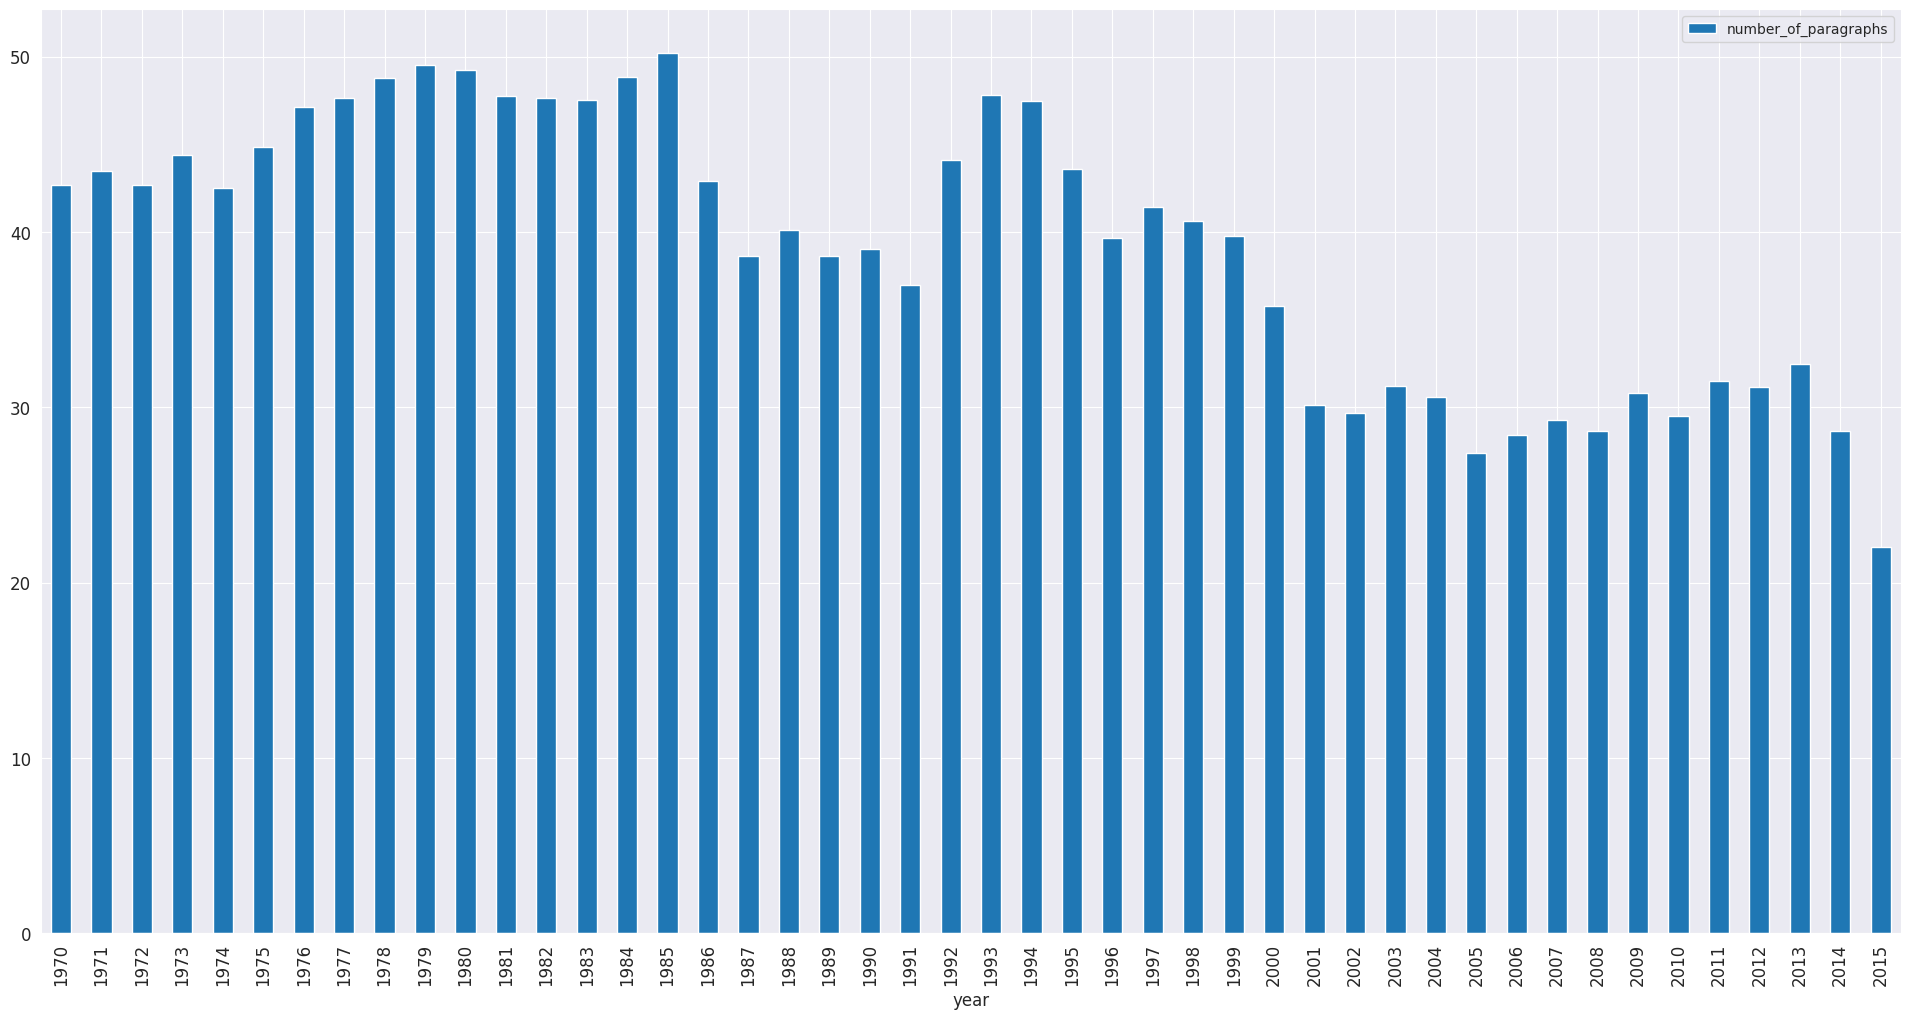

In [ ]:
%matplotlib inline
df.groupby('year').agg({'number_of_paragraphs': 'mean'}).plot.bar(figsize=(24,12))
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.lang.en.stop_words import STOP_WORDS as stopwords

In [ ]:
tfidf_text_vectorizer = TfidfVectorizer(stop_words=list(stopwords), min_df=5, max_df=0.7)
tfidf_text_vectors = tfidf_text_vectorizer.fit_transform(df['text'])
tfidf_text_vectors.shape

(7507, 24611)

In [ ]:
df.head(2)

,session,year,country,country_name,speaker,position,text,paragraphs,number_of_paragraphs
0,25,1970,ALB,Albania,Mr. NAS,NaN,33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly?\n34.\tIn taking up the...,"[33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly, 34.\tIn taking up the...",60
1,25,1970,ARG,Argentina,Mr. DE PABLO PARDO,NaN,"177.\t : It is a fortunate coincidence that precisely at a time when the United Nations is celebrating its first twenty-five years of existence, an eminent jurist so closely linked to our Organiza...","[177.\t : It is a fortunate coincidence that precisely at a time when the United Nations is celebrating its first twenty-five years of existence, an eminent jurist so closely linked to our Organiz...",50


In [ ]:
# flatten the paragraphs keeping the years
paragraph_df = pd.DataFrame([{ "text": paragraph, "year": year }
                               for paragraphs, year in zip(df["paragraphs"], df["year"])
                                    for paragraph in paragraphs if paragraph])

In [ ]:
paragraph_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282210 entries, 0 to 282209
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    282210 non-null  object
 1   year    282210 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.3+ MB


In [ ]:
paragraph_df.head(2)

,text,year
0,33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly,1970
1,"34.\tIn taking up the work on the agenda of the twenty- fifth session of the General Assembly, which is being held on the eve of the twenty-fifth anniversary of the coming into force of the Charte...",1970


In [ ]:
tfidf_para_vectorizer = TfidfVectorizer(stop_words=list(stopwords), min_df=5, max_df=0.7)
tfidf_para_vectors = tfidf_para_vectorizer.fit_transform(paragraph_df["text"])
tfidf_para_vectors.shape

(282210, 25165)

In [ ]:
par_df = df[['year','paragraphs']].explode("paragraphs")
display(par_df.info())
display(par_df.head(2))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287346 entries, 0 to 7506
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   year        287346 non-null  int64 
 1   paragraphs  287346 non-null  object
dtypes: int64(1), object(1)
memory usage: 6.6+ MB


None

,year,paragraphs
0,1970,33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly
0,1970,"34.\tIn taking up the work on the agenda of the twenty- fifth session of the General Assembly, which is being held on the eve of the twenty-fifth anniversary of the coming into force of the Charte..."


In [ ]:
(par_df['paragraphs'] != '').sum()

282210

In [ ]:
par_df = par_df[par_df['paragraphs'] != '']
display(par_df.info())
display(par_df.head(2))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 282210 entries, 0 to 7506
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   year        282210 non-null  int64 
 1   paragraphs  282210 non-null  object
dtypes: int64(1), object(1)
memory usage: 6.5+ MB


None

,year,paragraphs
0,1970,33: May I first convey to our President the congratulations of the Albanian delegation on his election to the Presidency of the twenty-fifth session of the General Assembly
0,1970,"34.\tIn taking up the work on the agenda of the twenty- fifth session of the General Assembly, which is being held on the eve of the twenty-fifth anniversary of the coming into force of the Charte..."


# Non Negative Matrix Factorization (NMF)

## Speeches

In [ ]:
%%time
from sklearn.decomposition import NMF

nmf_text_model = NMF(n_components=10, random_state=42)
W_text_matrix = nmf_text_model.fit_transform(tfidf_text_vectors)
H_text_matrix = nmf_text_model.components_

CPU times: user 21.1 s, sys: 14.6 s, total: 35.7 s
Wall time: 18.5 s


In [ ]:
tfidf_text_vectors.shape, W_text_matrix.shape, H_text_matrix.shape

((7507, 24611), (7507, 10), (10, 24611))

In [ ]:
W_text_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.57366588e-05, 3.61243821e-03, 0.00000000e+00],
       [4.76353080e-02, 0.00000000e+00, 0.00000000e+00, ...,
        4.66348986e-03, 2.33476496e-02, 0.00000000e+00],
       [4.19271203e-02, 1.14024589e-03, 3.64467647e-03, ...,
        2.60323411e-02, 1.31728452e-02, 2.95017949e-03],
       ...,
       [0.00000000e+00, 8.13669232e-02, 7.87160554e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 9.12564795e-02, 2.53548081e-02, ...,
        0.00000000e+00, 0.00000000e+00, 9.93224815e-03],
       [0.00000000e+00, 6.33861827e-02, 6.22941372e-02, ...,
        0.00000000e+00, 1.26829600e-02, 0.00000000e+00]])

In [ ]:
H_text_matrix

array([[3.30467898e-04, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.06919109e-03],
       [0.00000000e+00, 5.73889067e-02, 2.64588583e-04, ...,
        5.85726968e-03, 6.21973651e-03, 0.00000000e+00],
       [0.00000000e+00, 2.34578067e-02, 4.20985016e-04, ...,
        4.05910588e-03, 0.00000000e+00, 7.74577648e-04],
       ...,
       [0.00000000e+00, 3.14892060e-04, 0.00000000e+00, ...,
        7.27105453e-03, 5.88730940e-04, 0.00000000e+00],
       [3.94574630e-04, 3.31174534e-02, 1.11564965e-05, ...,
        0.00000000e+00, 3.94961485e-03, 0.00000000e+00],
       [1.29333740e-04, 1.07789358e-02, 0.00000000e+00, ...,
        1.14988155e-03, 5.61876603e-03, 0.00000000e+00]])

In [ ]:
def display_topics(model, features, no_top_words=5):
    for topic, words in enumerate(model.components_):
        total = words.sum()
        largest = words.argsort()[::-1] # invert sort order
        print("\nTopic %02d" % topic)
        for i in range(0, no_top_words):
            print("  %s (%2.2f)" % (features[largest[i]], abs(words[largest[i]]*100.0/total)))

In [ ]:
display_topics(nmf_text_model, tfidf_text_vectorizer.get_feature_names_out())


Topic 00
  co (0.79)
  operation (0.65)
  disarmament (0.36)
  nuclear (0.34)
  relations (0.25)

Topic 01
  terrorism (0.38)
  challenges (0.32)
  sustainable (0.30)
  millennium (0.29)
  reform (0.28)

Topic 02
  africa (1.15)
  african (0.82)
  south (0.63)
  namibia (0.36)
  delegation (0.30)

Topic 03
  arab (1.02)
  israel (0.89)
  palestinian (0.60)
  lebanon (0.54)
  israeli (0.54)

Topic 04
  american (0.33)
  america (0.31)
  latin (0.31)
  panama (0.21)
  bolivia (0.21)

Topic 05
  pacific (1.55)
  islands (1.23)
  solomon (0.86)
  island (0.82)
  fiji (0.71)

Topic 06
  soviet (0.81)
  republic (0.78)
  nuclear (0.68)
  viet (0.64)
  socialist (0.63)

Topic 07
  guinea (4.26)
  equatorial (1.75)
  bissau (1.53)
  papua (1.47)
  republic (0.57)

Topic 08
  european (0.61)
  europe (0.44)
  cooperation (0.39)
  bosnia (0.34)
  herzegovina (0.30)

Topic 09
  caribbean (0.98)
  small (0.66)
  bahamas (0.63)
  saint (0.63)
  barbados (0.61)


In [ ]:
W_text_matrix.sum(axis=0)/W_text_matrix.sum()*100.0

array([11.06189432, 17.0213082 , 13.6565622 , 10.18695452, 11.35821532,
        5.95003141,  7.90001101,  4.13937503, 11.91132462,  6.81432338])

## Paragraphs

In [ ]:
%%time
nmf_para_model = NMF(n_components=10, random_state=42)
W_para_matrix = nmf_para_model.fit_transform(tfidf_para_vectors)
H_para_matrix = nmf_para_model.components_

CPU times: user 37.2 s, sys: 19.6 s, total: 56.8 s
Wall time: 34.3 s


In [ ]:
tfidf_para_vectors

In [ ]:
display_topics(nmf_para_model, tfidf_para_vectorizer.get_feature_names_out())


Topic 00
  nations (5.63)
  united (5.52)
  organization (1.27)
  states (1.03)
  charter (0.93)

Topic 01
  general (2.87)
  session (2.83)
  assembly (2.81)
  mr (1.98)
  president (1.81)

Topic 02
  countries (4.44)
  developing (2.49)
  economic (1.49)
  developed (1.35)
  trade (0.92)

Topic 03
  people (1.36)
  peace (1.34)
  east (1.28)
  middle (1.17)
  palestinian (1.15)

Topic 04
  nuclear (4.93)
  weapons (3.27)
  disarmament (2.01)
  treaty (1.70)
  proliferation (1.46)

Topic 05
  rights (6.49)
  human (6.18)
  respect (1.15)
  fundamental (0.86)
  universal (0.82)

Topic 06
  africa (3.83)
  south (3.32)
  african (1.70)
  namibia (1.38)
  apartheid (1.19)

Topic 07
  security (6.13)
  council (5.89)
  permanent (1.50)
  reform (1.48)
  peace (1.30)

Topic 08
  international (2.05)
  world (1.50)
  community (0.92)
  new (0.77)
  peace (0.67)

Topic 09
  development (4.47)
  sustainable (1.18)
  economic (1.07)
  social (1.00)
  goals (0.93)


In [ ]:
W_para_matrix.sum(axis=0)/W_para_matrix.sum()*100.0

array([10.39275663, 10.28260827, 10.1767478 , 10.0886768 ,  6.63098011,
        7.32749985,  8.85488757,  8.28382717, 16.96763999, 10.99437581])

# TruncatedSVD

In [ ]:
%%time
from sklearn.decomposition import TruncatedSVD

svd_para_model = TruncatedSVD(n_components = 10, random_state=42)
W_svd_para_matrix = svd_para_model.fit_transform(tfidf_para_vectors)
H_svd_para_matrix = svd_para_model.components_

CPU times: user 5.02 s, sys: 12.3 s, total: 17.3 s
Wall time: 3.45 s


In [ ]:
tfidf_para_vectors.shape, W_svd_para_matrix.shape, H_svd_para_matrix.shape

((282210, 25165), (282210, 10), (10, 25165))

In [ ]:
display_topics(svd_para_model, tfidf_para_vectorizer.get_feature_names_out())


Topic 00
  nations (0.67)
  united (0.65)
  international (0.58)
  peace (0.46)
  world (0.46)

Topic 01
  general (14.04)
  assembly (13.09)
  session (12.94)
  mr (10.02)
  president (8.59)

Topic 02
  countries (19.15)
  development (14.61)
  economic (13.91)
  developing (13.00)
  session (10.29)

Topic 03
  nations (4.41)
  united (4.06)
  development (0.95)
  organization (0.84)
  charter (0.80)

Topic 04
  nuclear (21.13)
  weapons (14.01)
  disarmament (9.02)
  treaty (7.23)
  proliferation (6.31)

Topic 05
  rights (29.50)
  human (28.81)
  nuclear (9.20)
  weapons (6.42)
  respect (4.98)

Topic 06
  africa (8.73)
  south (8.24)
  united (3.91)
  african (3.71)
  nations (3.41)

Topic 07
  council (14.96)
  security (13.38)
  africa (8.50)
  south (6.11)
  african (3.94)

Topic 08
  world (48.49)
  international (41.03)
  peace (32.98)
  community (23.27)
  africa (22.00)

Topic 09
  development (63.98)
  sustainable (20.78)
  peace (20.74)
  goals (15.92)
  africa (15.61)


In [ ]:
svd_para_model.singular_values_

array([71.7166257 , 39.41222059, 36.59092542, 34.95099911, 33.35379448,
       31.56193554, 29.96968338, 28.79401884, 27.08035355, 26.8585253 ])

# LDA

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
count_para_vectorizer = CountVectorizer(stop_words=list(stopwords), min_df=5, max_df=0.7)
count_para_vectors = count_para_vectorizer.fit_transform(paragraph_df["text"])
count_para_vectors.shape

(282210, 25165)

In [ ]:
%%time
from sklearn.decomposition import LatentDirichletAllocation

lda_para_model = LatentDirichletAllocation(n_components = 10, random_state=42, n_jobs=-1)
W_lda_para_matrix = lda_para_model.fit_transform(count_para_vectors)
H_lda_para_matrix = lda_para_model.components_

CPU times: user 21.4 s, sys: 2.54 s, total: 23.9 s
Wall time: 5min 20s


In [ ]:
W_lda_para_matrix.shape, H_lda_para_matrix.shape

((282210, 10), (10, 25165))

In [ ]:
display_topics(lda_para_model, count_para_vectorizer.get_feature_names_out())


Topic 00
  africa (2.31)
  people (1.91)
  south (1.54)
  namibia (0.86)
  struggle (0.75)

Topic 01
  republic (1.52)
  government (1.38)
  united (1.21)
  peace (1.20)
  people (1.04)

Topic 02
  general (4.20)
  assembly (3.62)
  session (3.37)
  president (2.34)
  mr (2.31)

Topic 03
  human (3.57)
  rights (3.43)
  international (1.81)
  terrorism (1.01)
  law (0.98)

Topic 04
  world (2.23)
  countries (1.19)
  people (0.99)
  years (0.85)
  today (0.63)

Topic 05
  peace (1.72)
  security (1.61)
  middle (1.33)
  east (1.33)
  israel (1.24)

Topic 06
  countries (3.12)
  development (2.80)
  economic (2.21)
  developing (1.59)
  international (1.49)

Topic 07
  nuclear (3.14)
  weapons (2.32)
  disarmament (1.82)
  states (1.47)
  arms (1.46)

Topic 08
  nations (5.56)
  united (5.17)
  organization (1.46)
  security (1.46)
  international (1.45)

Topic 09
  international (1.94)
  world (1.92)
  peace (1.61)
  economic (1.00)
  relations (0.98)


In [ ]:
W_lda_para_matrix.sum(axis=0)/W_lda_para_matrix.sum()*100.0

array([ 7.93472644, 10.79117877,  7.5726238 ,  7.80524955,  8.62043817,
        8.41778207, 13.66893212,  6.44419589, 15.54857727, 13.19629591])

In [ ]:
try:
  import pyLDAvis.sklearn
except:
  !pip install google-colab pyldavis fastapi kaleido python-multipart uvicorn
  import pyLDAvis.sklearn

In [ ]:
"""
pyLDAvis sklearn
===============
Helper functions to visualize sklearn's LatentDirichletAllocation models
"""

import funcy as fp
import pyLDAvis


def _get_doc_lengths(dtm):
    return dtm.sum(axis=1).getA1()


def _get_term_freqs(dtm):
    return dtm.sum(axis=0).getA1()


def _get_vocab(vectorizer):
    return vectorizer.get_feature_names_out()


def _row_norm(dists):
    # row normalization function required
    # for doc_topic_dists and topic_term_dists
    return dists / dists.sum(axis=1)[:, None]


def _get_doc_topic_dists(lda_model, dtm):
    return _row_norm(lda_model.transform(dtm))


def _get_topic_term_dists(lda_model):
    return _row_norm(lda_model.components_)


def _extract_data(lda_model, dtm, vectorizer):
    vocab = _get_vocab(vectorizer)
    doc_lengths = _get_doc_lengths(dtm)
    term_freqs = _get_term_freqs(dtm)
    topic_term_dists = _get_topic_term_dists(lda_model)
    err_msg = ('Topic-term distributions and document-term matrix'
               'have different number of columns, {} != {}.')

    assert term_freqs.shape[0] == len(vocab), \
        ('Term frequencies and vocabulary are of different sizes, {} != {}.'
         .format(term_freqs.shape[0], len(vocab)))

    assert topic_term_dists.shape[1] == dtm.shape[1], \
        (err_msg.format(topic_term_dists.shape[1], len(vocab)))

    # column dimensions of document-term matrix and topic-term distributions
    # must match first before transforming to document-topic distributions
    doc_topic_dists = _get_doc_topic_dists(lda_model, dtm)
    return {'vocab': vocab,
            'doc_lengths': doc_lengths.tolist(),
            'term_frequency': term_freqs.tolist(),
            'doc_topic_dists': doc_topic_dists.tolist(),
            'topic_term_dists': topic_term_dists.tolist()}


def prepare(lda_model, dtm, vectorizer, **kwargs):
    """Create Prepared Data from sklearn's LatentDirichletAllocation and CountVectorizer.

    Parameters
    ----------
    lda_model : sklearn.decomposition.LatentDirichletAllocation.
        Latent Dirichlet Allocation model from sklearn fitted with `dtm`

    dtm : array-like or sparse matrix, shape=(n_samples, n_features)
        Document-term matrix used to fit on LatentDirichletAllocation model (`lda_model`)

    vectorizer : sklearn.feature_extraction.text.(CountVectorizer, TfIdfVectorizer).
        vectorizer used to convert raw documents to document-term matrix (`dtm`)

    **kwargs: Keyword argument to be passed to pyLDAvis.prepare()


    Returns
    -------
    prepared_data : PreparedData
          the data structures used in the visualization


    Example
    --------
    For example usage please see this notebook:
    http://nbviewer.ipython.org/github/bmabey/pyLDAvis/blob/master/notebooks/sklearn.ipynb

    See
    ------
    See `pyLDAvis.prepare` for **kwargs.
    """
    opts = fp.merge(_extract_data(lda_model, dtm, vectorizer), kwargs)
    return pyLDAvis.prepare(**opts)


In [ ]:
lda_display = prepare(lda_para_model, count_para_vectors, count_para_vectorizer, sort_topics=False)
pyLDAvis.display(lda_display)

In [ ]:
lda_tsne_display = prepare(lda_para_model, count_para_vectors, count_para_vectorizer, sort_topics=False, mds='tsne')
pyLDAvis.display(lda_tsne_display)

# Display Topic Models and Compare as Wordclouds

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def wordcloud_topics(model, features, no_top_words=40):
    for topic, words in enumerate(model.components_):
        size = {}
        largest = words.argsort()[::-1] # invert sort order
        for i in range(0, no_top_words):
            size[features[largest[i]]] = abs(words[largest[i]])
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        wc.generate_from_frequencies(size)
        plt.figure(figsize=(12,12))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        # if you don't want to save the topic model, comment the next line
        plt.savefig(f'topic{topic}.png')

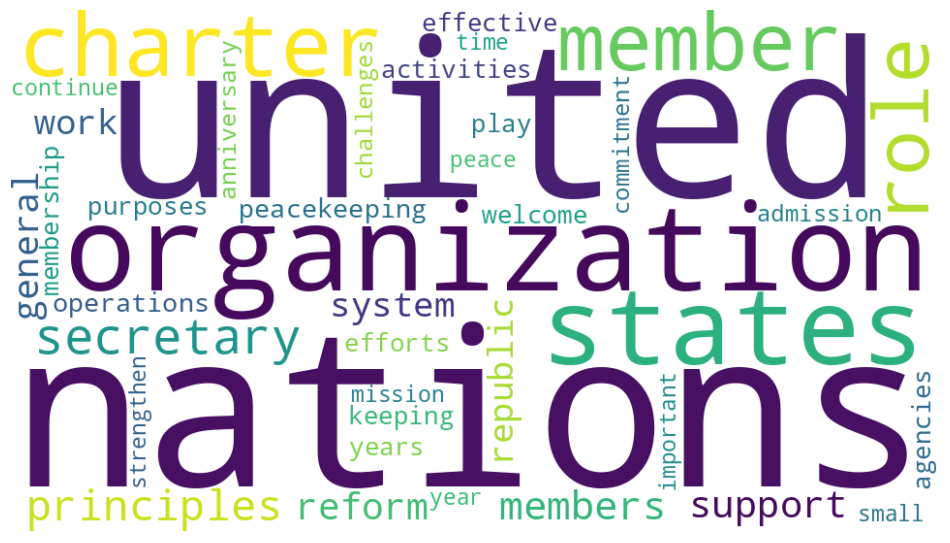

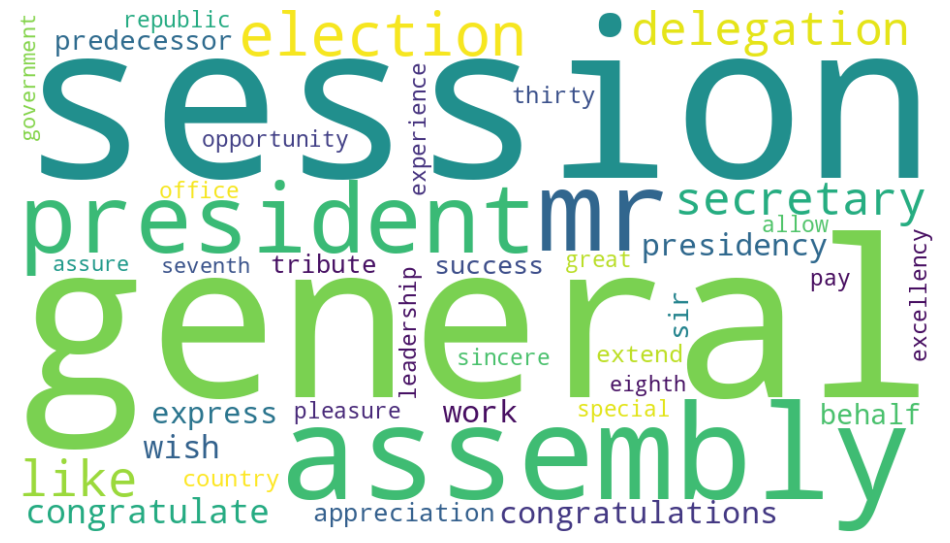

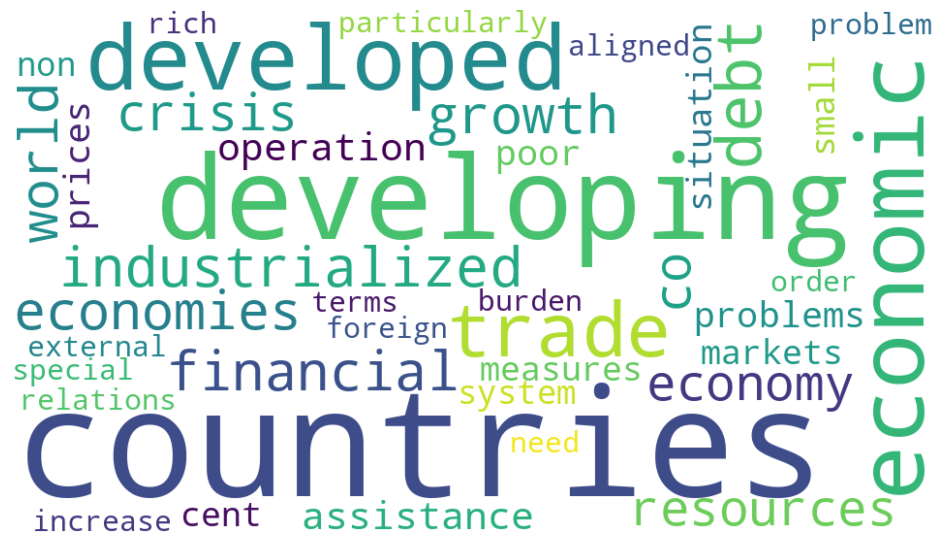

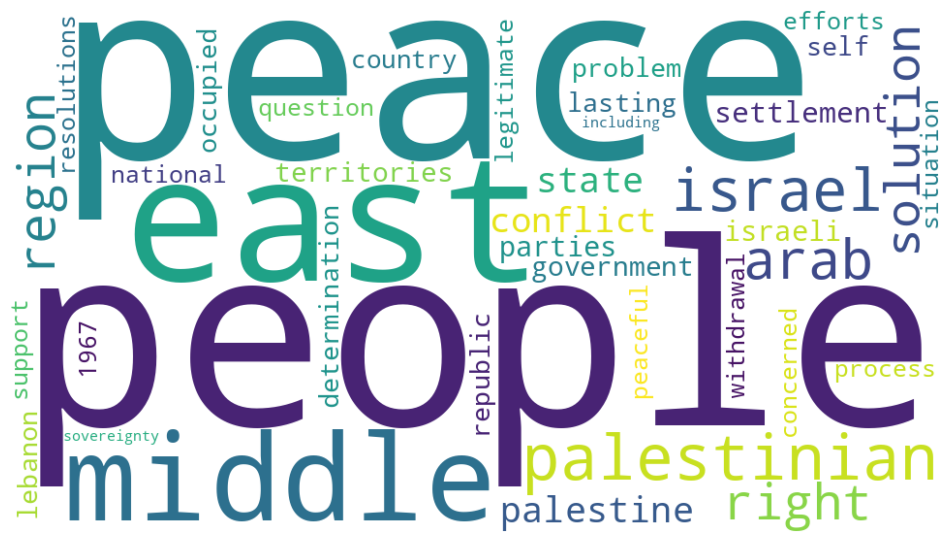

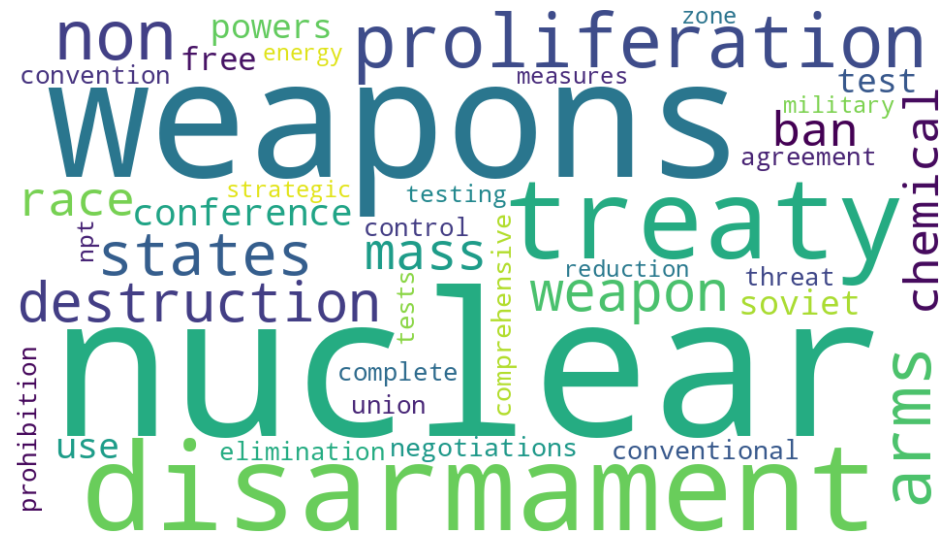

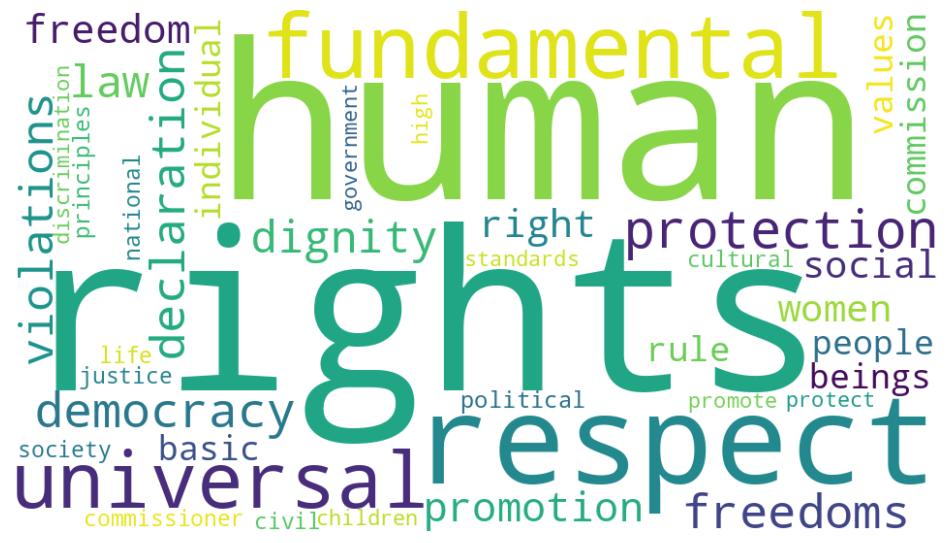

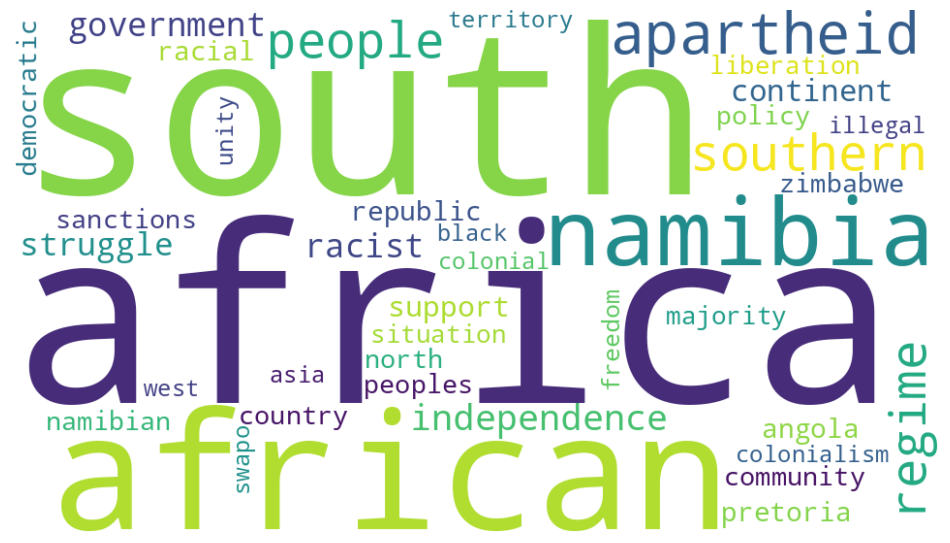

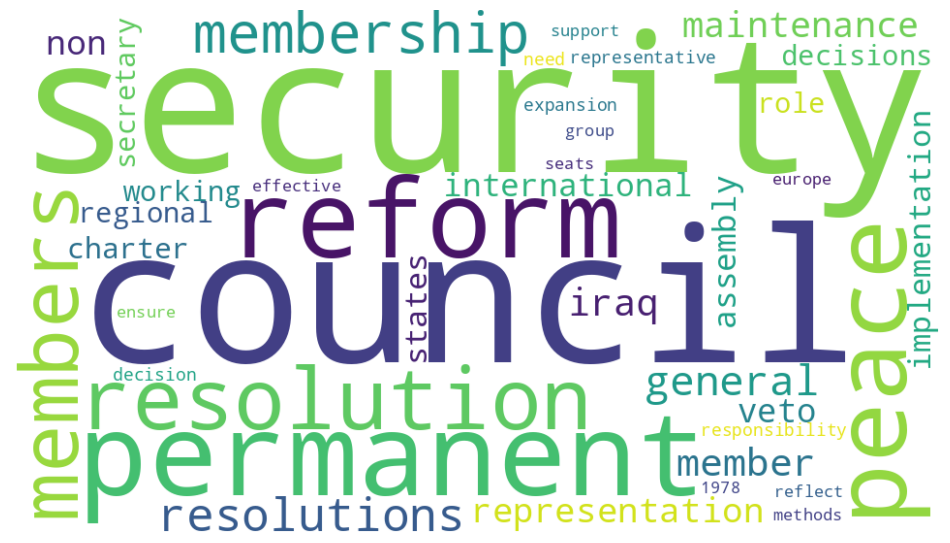

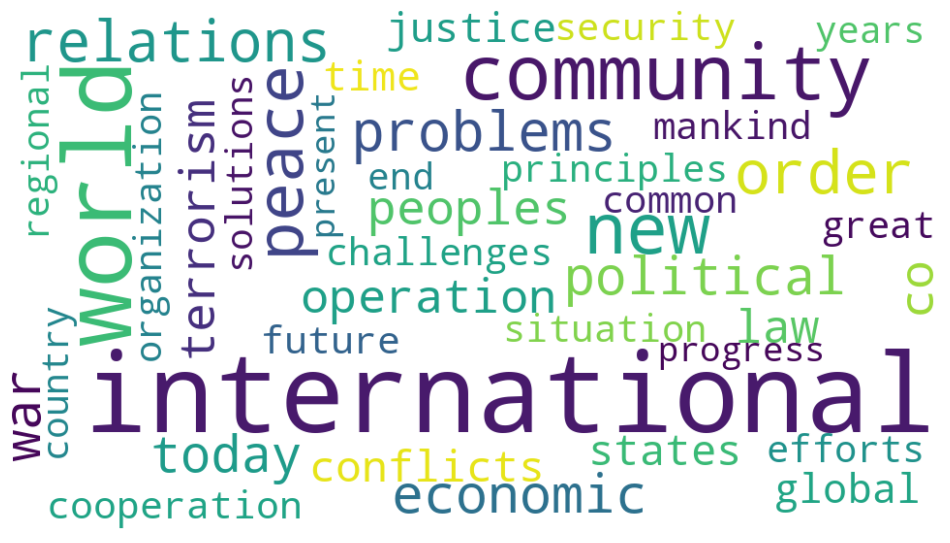

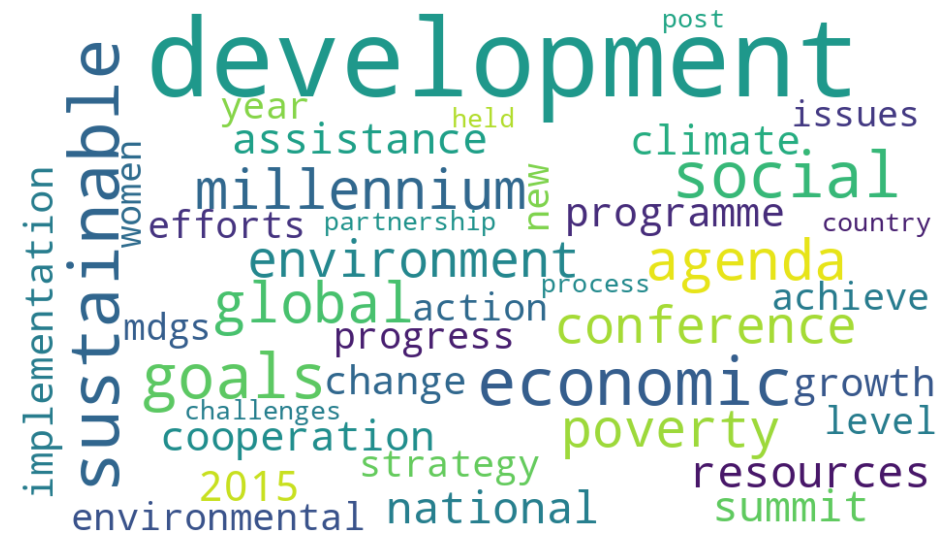

In [ ]:
wordcloud_topics(nmf_para_model, tfidf_para_vectorizer.get_feature_names_out())

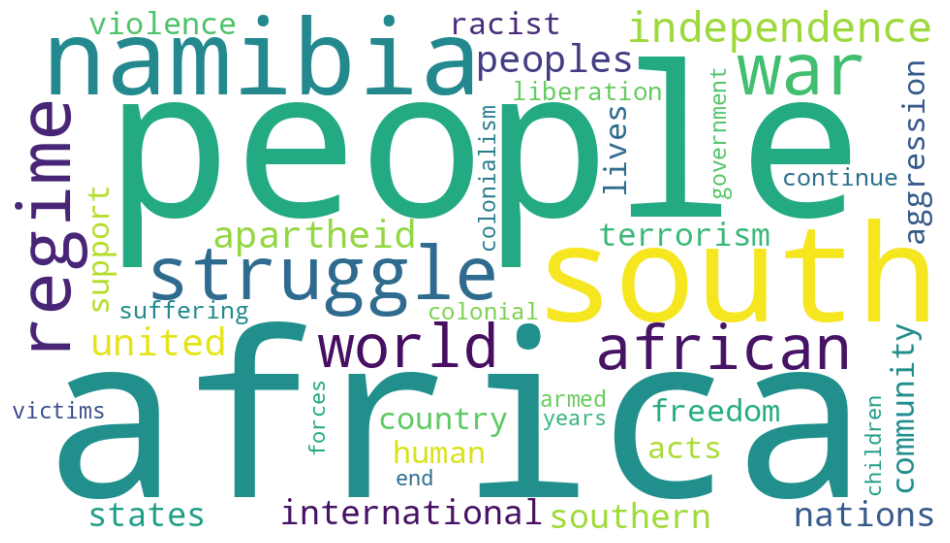

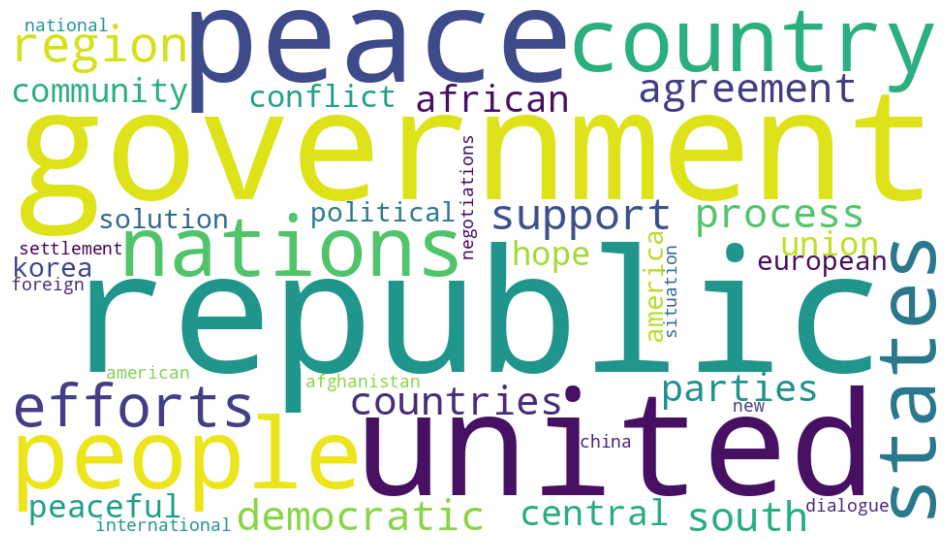

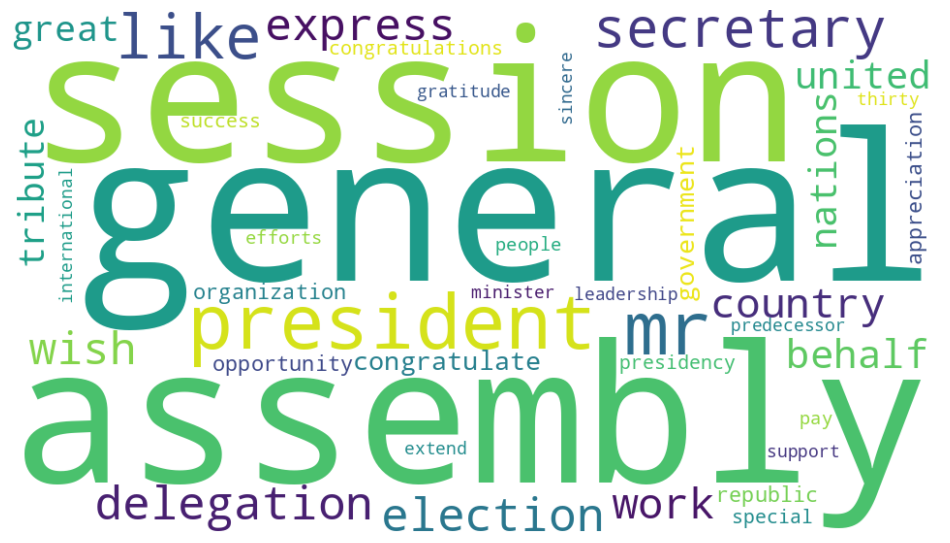

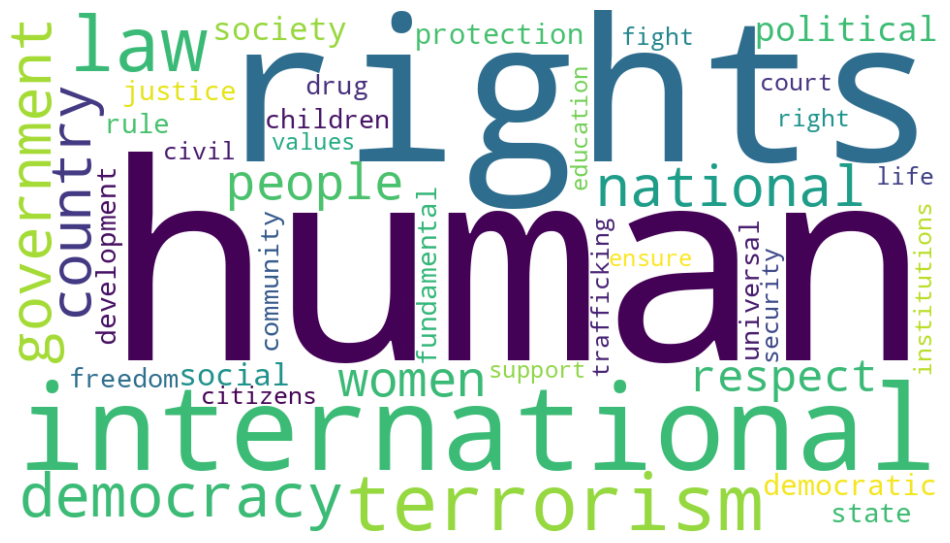

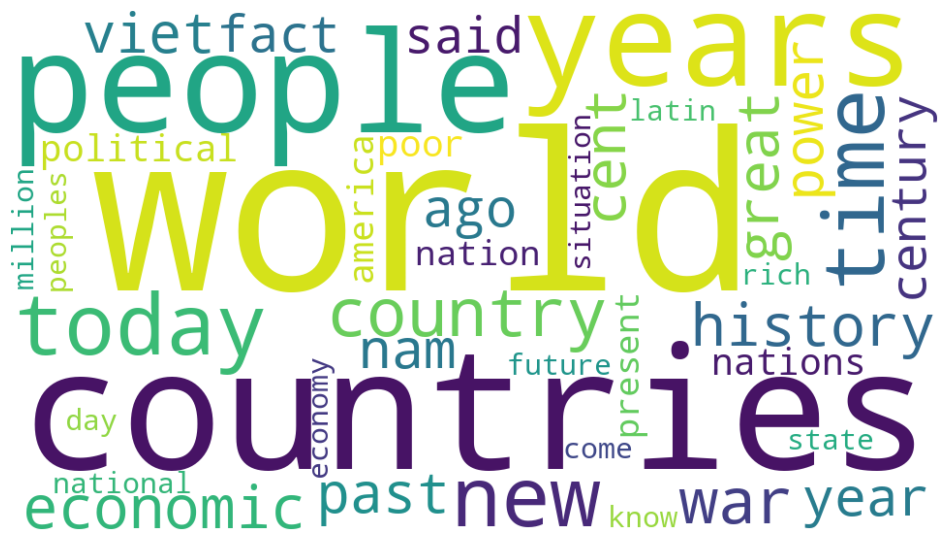

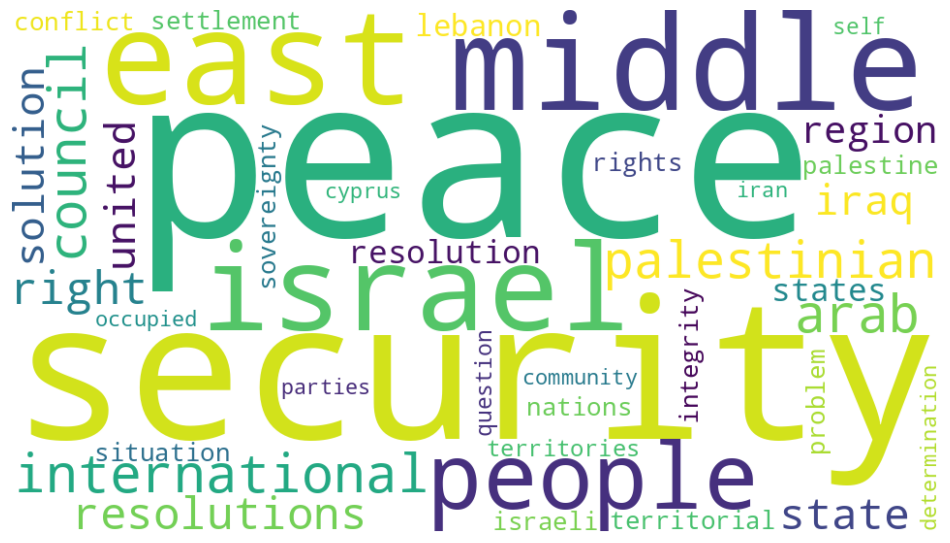

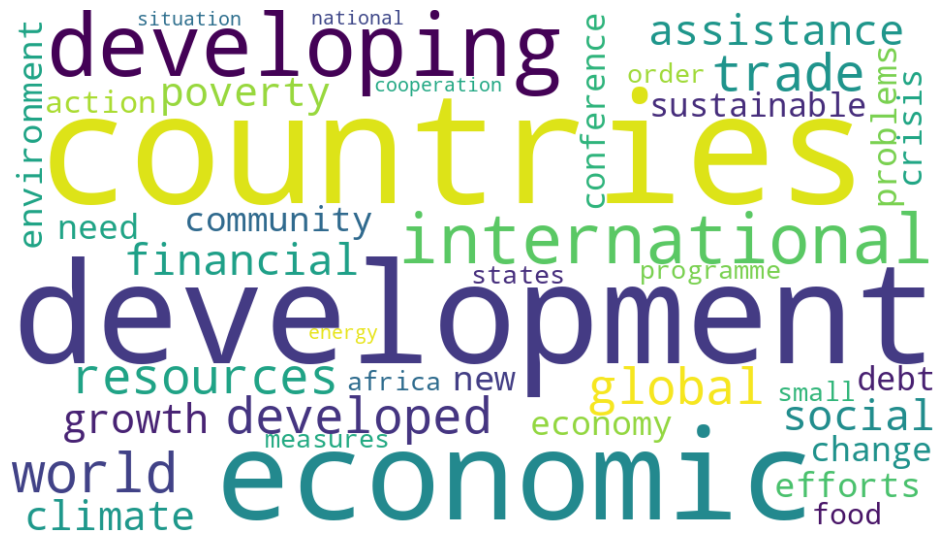

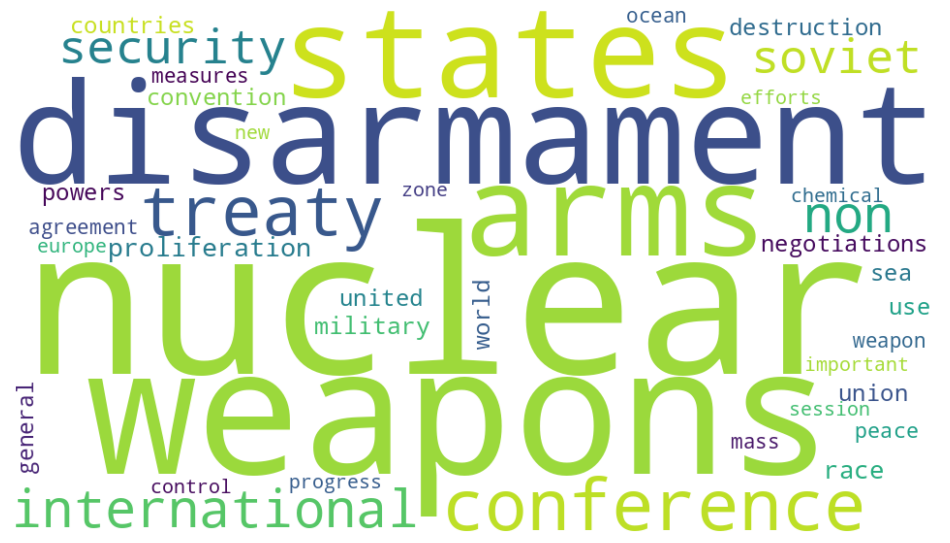

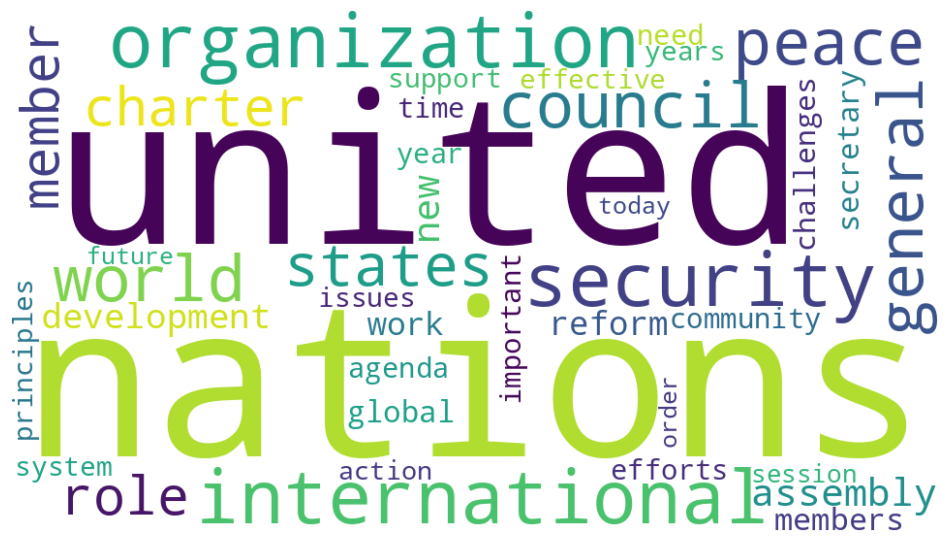

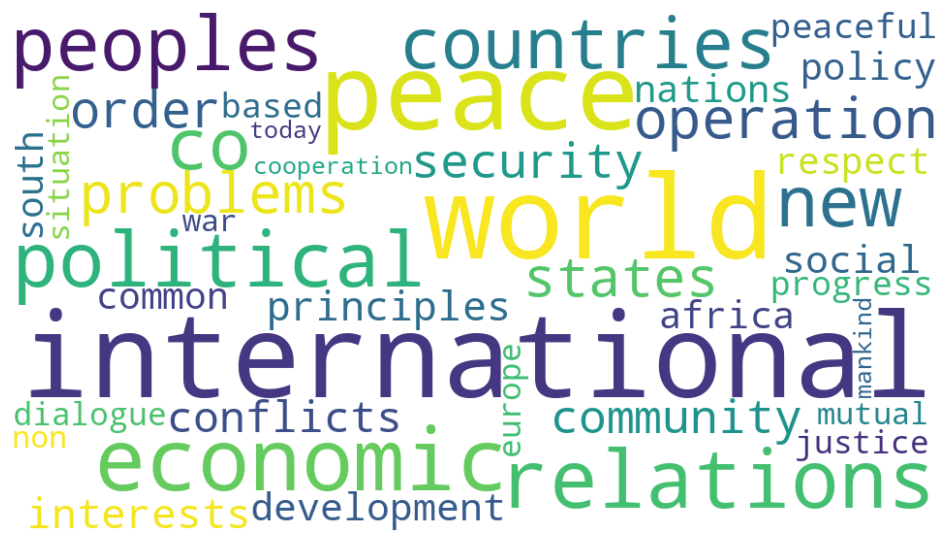

In [ ]:
wordcloud_topics(lda_para_model, count_para_vectorizer.get_feature_names_out())

# Time Development of Topic Models

In [ ]:
W_para_matrix.sum(axis=0)/W_para_matrix.sum()*100.0

In [ ]:
import numpy as np
before_1990 = np.array(paragraph_df["year"] < 1990)
after_1990 = ~ before_1990

In [ ]:
W_para_matrix_early = nmf_para_model.transform(tfidf_para_vectors[before_1990])
W_para_matrix_late  = nmf_para_model.transform(tfidf_para_vectors[after_1990])
print(W_para_matrix_early.sum(axis=0)/W_para_matrix_early.sum()*100.0)
print(W_para_matrix_late.sum(axis=0)/W_para_matrix_late.sum()*100.0)

In [ ]:
['%1.2f'%x for x in W_para_matrix_early.sum(axis=0)/W_para_matrix_early.sum()*100.0]

In [ ]:
['%1.2f'%x for x in W_para_matrix_early.sum(axis=0)/W_para_matrix_late.sum()*100.0]

In [ ]:
from tqdm.auto import tqdm
import numpy as np
year_data = []
for year in tqdm(np.unique(np.unique(paragraph_df["year"]))):
    W_year = nmf_para_model.transform(tfidf_para_vectors[np.array(paragraph_df["year"] == year)])
    year_data.append([year] + list(W_year.sum(axis=0)/W_year.sum()*100.0))

In [ ]:
topic_names = []
voc = tfidf_para_vectorizer.get_feature_names_out()
for topic in nmf_para_model.components_:
    important = topic.argsort()
    top_word = voc[important[-1]] + " " + voc[important[-2]]
    topic_names.append("Topic " + top_word)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df_year = pd.DataFrame(year_data, columns=["year"] + topic_names).set_index("year")
df_year.plot.area(figsize=(16,9))

In [ ]:
[f'Topic {count_para_vectorizer.get_feature_names_out()[words.argsort()[-1]]}' for words in nmf_para_model.components_]

In [ ]:
df_year.plot()

# Optimal number of topics

In [ ]:
lda_para_model.perplexity(tfidf_para_vectors)

In [ ]:
from tqdm.auto import tqdm
lda_para_model_n = []
for n in tqdm(range(5, 21)):
    lda_model = LatentDirichletAllocation(n_components = n, random_state=42)
    lda_model.fit_transform(count_para_vectors)
    lda_perplexity = lda_model.perplexity(tfidf_para_vectors)
    lda_para_model_n.append((lda_model, lda_perplexity))

In [ ]:
lda_para_model_n

# Clustering

In [ ]:
%%time

from sklearn.cluster import KMeans
k_means_para = KMeans(n_clusters=10, random_state=42)
k_means_para.fit(tfidf_para_vectors)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f95683953f0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 847, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 984, in _make_controller_from_path
    lib_controller = controller_class(filepath=filepath, prefix=prefix)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 111, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: /usr/local/lib/python3.10/dist-packages/numpy.libs/libopenblas64_p-r0-742d56dc.3.20.so: cannot open shared object file: No such file or directory


CPU times: user 3min 35s, sys: 3.53 s, total: 3min 38s
Wall time: 53.4 s


KMeans(n_clusters=10, random_state=42)

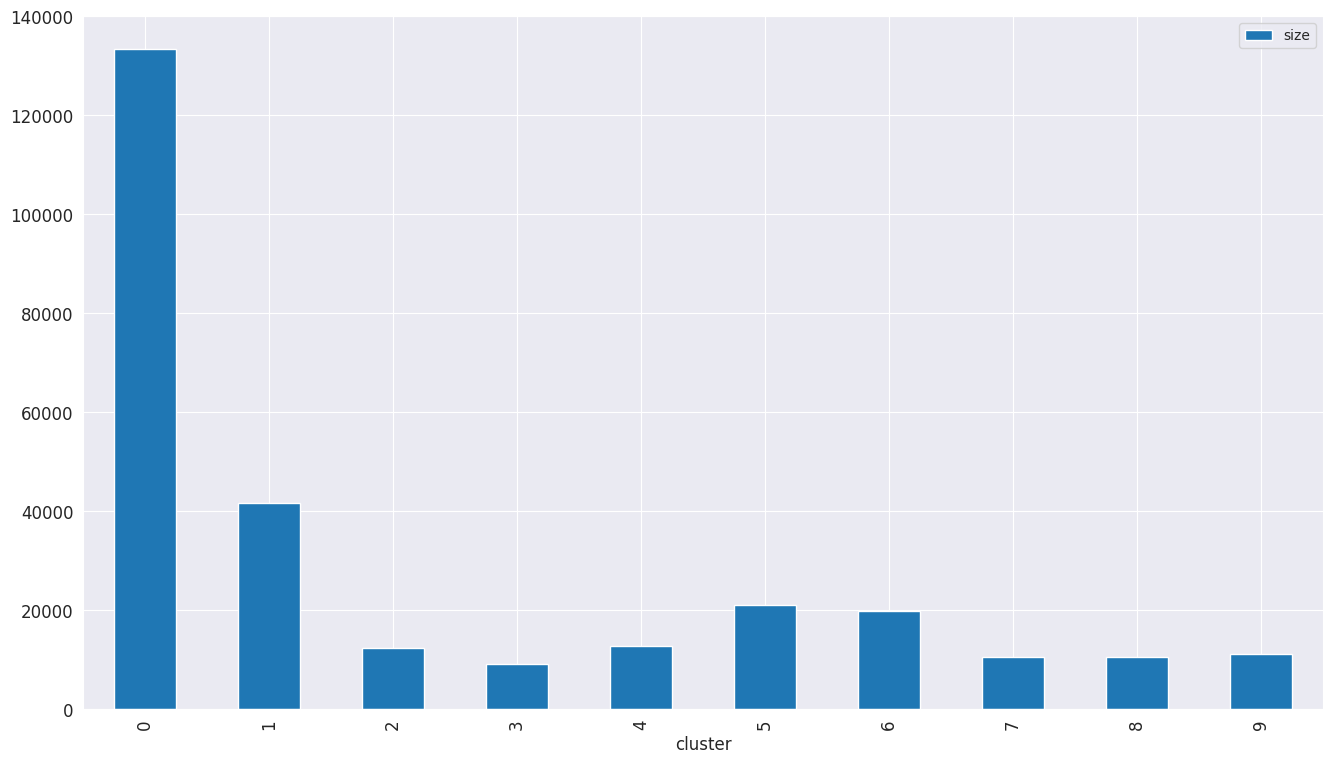

In [ ]:
sizes = []
for i in range(10):
    sizes.append({"cluster": i, "size": np.sum(k_means_para.labels_==i)})
df_cluster = pd.DataFrame(sizes).set_index("cluster")
ax = df_cluster.plot.bar(figsize=(16,9))
fig = ax.get_figure()
fig.savefig("cluster-size.svg")

In [ ]:
df_cluster

,size
cluster,
0,133370
1,41705
2,12396
3,9142
4,12674
5,21080
6,19727
7,10563
8,10437


# Gensim

In [ ]:
# create tokenized documents
gensim_paragraphs = [[w for w in re.findall(r'\b\w\w+\b' , paragraph.lower()) if w not in stopwords]
                           for paragraph in paragraph_df["text"]]

In [ ]:
from gensim.corpora import Dictionary

dict_gensim_para = Dictionary(gensim_paragraphs)

In [ ]:
dir(dict_gensim_para)

In [ ]:
dict_gensim_para.filter_extremes(no_below=5, no_above=0.7)

In [ ]:
bow_gensim_para = [dict_gensim_para.doc2bow(paragraph) for paragraph in gensim_paragraphs]

In [ ]:
bow_gensim_para

In [ ]:
from gensim.models import TfidfModel
tfidf_gensim_para = TfidfModel(bow_gensim_para)
vectors_gensim_para = tfidf_gensim_para[bow_gensim_para]

In [ ]:
dir(vectors_gensim_para)

## NMF

In [ ]:
from gensim.models.nmf import Nmf

nmf_gensim_para = Nmf(vectors_gensim_para, num_topics=10, id2word=dict_gensim_para, kappa=0.1, eval_every=5, random_state=42)

In [ ]:
def display_topics_gensim(model):
    for topic in range(0, model.num_topics):
        print("\nTopic %02d" % topic)
        for (word, prob) in model.show_topic(topic, topn=5):
            print("  %s (%2.2f)" % (word, prob))

In [ ]:
display_topics_gensim(nmf_gensim_para)

In [ ]:
from gensim.models.coherencemodel import CoherenceModel

nmf_gensim_para_coherence = CoherenceModel(model=nmf_gensim_para, texts=gensim_paragraphs, dictionary=dict_gensim_para, coherence='c_v')
nmf_gensim_para_coherence_score = nmf_gensim_para_coherence.get_coherence()
print(nmf_gensim_para_coherence_score)

## LDA

In [ ]:
from gensim.models import LdaModel
lda_gensim_para = LdaModel(corpus=bow_gensim_para, id2word=dict_gensim_para, chunksize=2000,
    alpha='auto', eta='auto', iterations=400, num_topics=10, passes=20, eval_every=None, random_state=42)

In [ ]:
display_topics_gensim(lda_gensim_para)

In [ ]:
lda_gensim_para.log_perplexity(vectors_gensim_para)

In [ ]:
from gensim.models.coherencemodel import CoherenceModel

lda_gensim_para_coherence = CoherenceModel(model=lda_gensim_para, texts=gensim_paragraphs, dictionary=dict_gensim_para, coherence='c_v')
lda_gensim_para_coherence_score = lda_gensim_para_coherence.get_coherence()
print(lda_gensim_para_coherence_score)

In [ ]:
print(lda_gensim_para_coherence_score)

In [ ]:
lda_gensim_para.alpha

In [ ]:
nmf_gensim_para_coherence = CoherenceModel(model=nmf_gensim_para, texts=gensim_paragraphs, dictionary=dict_gensim_para, coherence='c_v')
nmf_gensim_para_coherence_score = nmf_gensim_para_coherence.get_coherence()
print(nmf_gensim_para_coherence_score)

In [ ]:
top_topics = lda_gensim_para.top_topics(vectors_gensim_para, topn=5)
avg_topic_coherence = sum([t[1] for t in top_topics]) / len(top_topics)
print('Average topic coherence: %.4f.' % avg_topic_coherence)

In [ ]:
[(t[1], " ".join([w[1] for w in t[0]])) for t in top_topics]

## Optimize number of LDA topics

In [ ]:
from gensim.models.ldamulticore import LdaMulticore
lda_para_model_n = []
for n in tqdm(range(5, 21)):
    lda_model = LdaMulticore(corpus=bow_gensim_para, id2word=dict_gensim_para, chunksize=2000,
                             eta='auto', iterations=400, num_topics=n, passes=20,
                             eval_every=None, random_state=42, workers=7)
    lda_coherence = CoherenceModel(model=lda_model, texts=gensim_paragraphs,
                                   dictionary=dict_gensim_para, coherence='c_v')
    lda_para_model_n.append((n, lda_model, lda_coherence.get_coherence()))

In [ ]:
pd.DataFrame(lda_para_model_n, columns=["n", "model", "coherence"]).set_index("n")[["coherence"]].plot(figsize=(16,9))

In [ ]:
display_topics_gensim(lda_para_model_n[12][1])

In [ ]:
def wordcloud_topics_gensim(model, no_top_words=40):
    for topic in range(0, model.num_topics):
        size = {}
        for (word, prob) in model.show_topic(topic, topn=no_top_words):
            size[word] = prob
        wc = WordCloud(background_color="white", max_words=100, width=960, height=540)
        wc.generate_from_frequencies(size)
        plt.figure(figsize=(12,12))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        # if you don't want to save the topic model, comment the next line
        plt.savefig(f'topic{topic}.png')

In [ ]:
wordcloud_topics_gensim(lda_para_model_n[12][1])

## HDP

In [ ]:
from gensim.models import HdpModel
hdp_gensim_para = HdpModel(corpus=bow_gensim_para, id2word=dict_gensim_para)

In [ ]:
import re

In [ ]:
words = 8
pd.DataFrame([re.split(r" \+ |\*", t[1]) for t in hdp_gensim_para.print_topics(num_topics=20, num_words=words)])

In [ ]:
pd.set_option('max_colwidth', 1000)
pd.DataFrame(hdp_gensim_para.print_topics(num_topics=40, num_words=10), columns=["topic", "words"]).set_index("topic")

In [ ]:
hdp_gensim_para.show_topic(0, topn=10)

In [ ]:
def display_topics_gensim_hdp(model, num_topics):
    for topic in range(0, num_topics):
        print("\nTopic %02d" % topic)
        for (word, prob) in model.show_topic(topic, topn=10):
            print("  %s (%2.2f)" % (word, prob))

In [ ]:
display_topics_gensim_hdp(hdp_gensim_para, 50)